In [1]:
import os
os.chdir(r"D:\QGIS\online-GIS-programming-course\Week1_Analyzing_Airport_Data\data")
print("Working directory:", os.getcwd())


Working directory: D:\QGIS\online-GIS-programming-course\Week1_Analyzing_Airport_Data\data


In [2]:
import csv

f = open("Camp_stats.csv", encoding="utf-8")
for row in csv.reader(f):
    print(row)
f.close()


['Refugee_Camp_Name', 'Country', 'Population_2006', 'Population_2014']
['Kakuma', 'Kenya', '90457', '153959']
['Hagadera', 'Kenya', '59185', '106968']
['Adjumani', 'Uganda', '54051', '96926']
['Dagahaley', 'Kenya', '39526', '88486']
['Zaatari', 'Jordan', '0', '84773']


In [3]:
from math import cos, radians, sin, pow, asin, sqrt

def distance(lat1, long1, lat2, long2):
    radius = 6371
    lat1 = radians(lat1)
    lat2 = radians(lat2)
    long1 = radians(long1)
    long2 = radians(long2)
    dlat = lat2 - lat1
    dlon = long2 - long1
    a = pow(sin(dlat/2), 2) + cos(lat1) * cos(lat2) * pow(sin(dlon/2), 2)
    distance = 2 * radius * asin(sqrt(a))
    return distance

# Test: Melbourne to Berlin
distance(-37.814, 144.963, 52.519, 13.406)


15973.23775470765

In [4]:
import csv

f = open("airports.dat", encoding="utf-8")
for row in csv.reader(f):
    if row[3] == "Australia" or row[3] == "Russia":
        print(row[1])
f.close()


Yakutsk Airport
Mirny Airport
Ignatyevo Airport
Khabarovsk-Novy Airport
Provideniya Bay Airport
Sokol Airport
Pevek Airport
Yelizovo Airport
Yuzhno-Sakhalinsk Airport
Vladivostok International Airport
Chita-Kadala Airport
Bratsk Airport
Irkutsk Airport
Ulan-Ude Airport (Mukhino)
Pulkovo Airport
Murmansk Airport
Khrabrovo Airport
Abakan Airport
Barnaul Airport
Kemerovo Airport
Omsk Central Airport
Krasnodar Pashkovsky International Airport
Uytash Airport
Mineralnyye Vody Airport
Stavropol Shpakovskoye Airport
Platov International Airport
Sochi International Airport
Astrakhan Airport
Volgograd International Airport
Chelyabinsk Balandino Airport
Magnitogorsk International Airport
Nizhnevartovsk Airport
Bolshoye Savino Airport
Surgut Airport
Koltsovo Airport
Bryansk Airport
Sheremetyevo International Airport
Migalovo Air Base
Voronezh International Airport
Vnukovo International Airport
Syktyvkar Airport
Kazan International Airport
Orenburg Central Airport
Ufa International Airport
Kurumoch

In [ ]:
latitudes = {}
longitudes = {}

f = open("airports.dat", encoding="utf-8")
for row in csv.reader(f):
    airport_id = row[0]
    latitudes[airport_id] = float(row[6])
    longitudes[airport_id] = float(row[7])
f.close()

print("Total airports loaded:", len(latitudes))


Total airports loaded: 7698


In [6]:
distances = []

f = open("routes.dat", encoding="utf-8")
for row in csv.reader(f):
    source_airport = row[3]
    dest_airport = row[5]
    if source_airport in latitudes and dest_airport in latitudes:
        source_lat = latitudes[source_airport]
        source_long = longitudes[source_airport]
        dest_lat = latitudes[dest_airport]
        dest_long = longitudes[dest_airport]
        distances.append(distance(source_lat, source_long, dest_lat, dest_long))
f.close()

print("Total routes calculated:", len(distances))
print("Sample distances (km):", distances[:5])


Total routes calculated: 66771
Sample distances (km): [1506.825604458928, 1040.4383197669074, 448.164908709546, 770.5085001497805, 1338.6314665862067]


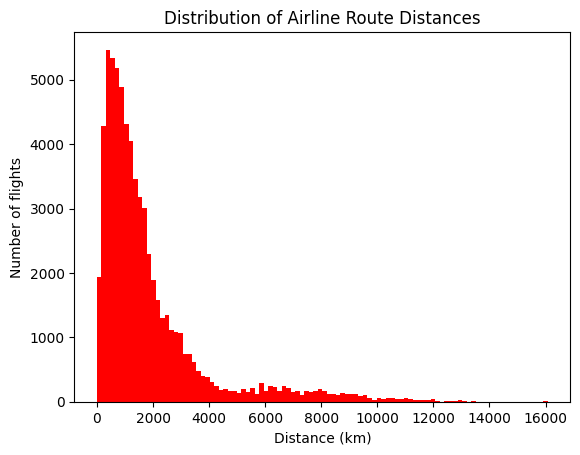

In [7]:
import numpy as np
import matplotlib.pyplot as plt

plt.hist(distances, 100, facecolor='r')
plt.xlabel("Distance (km)")
plt.ylabel("Number of flights")
plt.title("Distribution of Airline Route Distances")
plt.savefig("histogram.png")
plt.show()
